# Week 4: Fine Tuning ViT

## Methods

This notebook iterates on the Week 3 ViT with targeted changes to address overfitting and
improve real-class detection. Four changes were made simultaneously in a single experiment.
Because no ablation study was conducted, the individual contribution of each change cannot
be isolated — the results reflect the combined effect of all four modifications.

**Changes from Week 3:**
1. **Stronger augmentation:** RandAugment (num_ops=2, magnitude=9), RandomPerspective
   (distortion_scale=0.1, p=0.3), and RandomGrayscale (p=0.05) added to the training
   transform pipeline. Rotation range increased from ±10° to ±15°, color jitter strength
   increased (brightness/contrast 0.2→0.3).
2. **Label smoothing:** 0.1 added to CrossEntropyLoss. Instead of hard labels (0 or 1),
   targets become 0.05 and 0.95, reducing overconfident predictions and acting as a
   regularizer.
3. **More unfrozen layers:** Last 6 transformer blocks unfrozen instead of 3, increasing
   trainable parameters from 21.3M to 42.5M. This provides more capacity to learn
   deepfake-specific features but also increases overfitting risk — hence pairing with
   stronger regularization.
4. **GradScaler removed:** AMP mixed-precision training was disabled. Week 3 observations
   suggested it may have negatively affected accuracy, though this impact was not
   quantified in isolation.

**Unchanged from Week 3:** Optimizer (AdamW, weight_decay=0.01), learning rate (3e-5),
warmup schedule (2 epochs linear + cosine annealing), early stopping (patience 5),
batch size (64), class imbalance handling (WeightedRandomSampler + weighted loss).

**Key Hyperparameters:**
| Parameter | Value |
|---|---|
| Optimizer | AdamW (weight_decay=0.01) |
| Learning rate | 3e-5 |
| LR scheduler | Linear warmup (2 epochs) + cosine annealing |
| Batch size | 64 |
| Max epochs | 15 |
| Early stopping patience | 5 (on val AUC-ROC) |
| Label smoothing | 0.1 |
| Unfrozen blocks | Last 6 (42.5M trainable params) |
| Mixed precision | Disabled |
| GPU | NVIDIA A100 (Colab Pro) |

**Limitations of this experimental design:** All four changes were applied simultaneously.
To determine whether the gains came from regularization (augmentation + label smoothing)
or from increased model capacity (6 unfrozen blocks), at least one ablation experiment
would be needed — for example, training with label smoothing only while keeping 3 unfrozen
blocks and the original augmentation.

**general set up and libraries**

Standard setup: mount Google Drive, unzip frames to local runtime, import libraries. See Week 2 for library documentation.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q -o /content/drive/MyDrive/deepfake_capstone/frames.zip -d /content/

Mounted at /content/drive


In [ ]:
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: NVIDIA A100-SXM4-40GB


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import RandAugment
import timm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
from tqdm import tqdm
import os, copy, json, random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


In [ ]:
SEED = 301
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# Paths
DATA_DIR = '/content/frames'
CHECKPOINT_DIR = '/content/drive/MyDrive/deepfake_capstone/checkpoints/'
RESULTS_DIR = '/content/drive/MyDrive/deepfake_capstone/results/'

# Hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 15
PATIENCE = 5
LEARNING_RATE = 3e-5

# Data Set Up

This week targets the overfitting observed in Week 3 through stronger data augmentation and regularization.

The train transform we see here is everything that is being done to the training data. We have: horizontal flip, rotation is now + - 15 degrees now, some grayscale, perspective distortions. This is to make the first part of the effort to nail in generalization and tamper the overfitting away. RandAugment is the most advanced one that is being used, it will take a random number of augmentation operations and applies them to certain magnitudes. Val is the same as previous weeks and so is the dataset designations. The class weights we are inversing are being kept the same as previous weeks and we are keeping the workers to 4.





In [ ]:
data_dir = '/content/frames'

# Stronger augmentation to fight overfitting
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.3),
    RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=val_transform)

print(f"Classes: {train_dataset.classes}")
print(f"Class mapping: {train_dataset.class_to_idx}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Classes: ['fake', 'real']
Class mapping: {'fake': 0, 'real': 1}
Train: 195786, Val: 34636, Test: 20055


In [ ]:
train_targets = [s[1] for s in train_dataset.samples]
class_counts = np.bincount(train_targets)
print(f"Class counts - fake: {class_counts[0]}, real: {class_counts[1]}")

class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in train_targets]
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Batches per epoch - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Class counts - fake: 170930, real: 24856
Batches per epoch - Train: 3060, Val: 542, Test: 314


# Model Setup

The primary architectural change is unfreezing the last 6 transformer blocks instead of 3, increasing trainable parameters from 21.3M to 42.5M. This provides additional capacity to learn deepfake-specific features at the cost of higher overfitting risk, which is addressed by the augmentation and label smoothing changes above.

**loss, optimizer, and scheduler**
Now lets try smoothing the labels to get rid of the models over confident predictions, which should help hit the overfitting. Label smoothing is a regularization technique, instead of static, hard labels like 0 or 1, it softens them by adding a lil uniform distribution.

Everything else is the same from week 3


In [ ]:
# Load pretrained ViT-Base/16
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)

# Freeze everything
for param in model.parameters():
    param.requires_grad = False

# Thaw classifier head
for param in model.head.parameters():
    param.requires_grad = True

# Thaw layer norm
for param in model.norm.parameters():
    param.requires_grad = True

# Thaw last 6 blocks instead of 3
for param in model.blocks[-6:].parameters():
    param.requires_grad = True

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Trainable params: 42,530,306 / 85,800,194 (49.6%)


In [ ]:
# Weighted loss WITH label smoothing to reduce overconfidence
weight_tensor = torch.tensor([1.0, class_counts[0]/class_counts[1]], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weight_tensor, label_smoothing=0.1)
print(f"Loss weights - fake: {weight_tensor[0]:.2f}, real: {weight_tensor[1]:.2f}")
print("Label smoothing: 0.1")

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-5,
    weight_decay=0.01
)

NUM_EPOCHS = 15
warmup_epochs = 2
scheduler_cosine = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS - warmup_epochs, eta_min=1e-6)
scheduler_warmup = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, total_iters=warmup_epochs)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[scheduler_warmup, scheduler_cosine], milestones=[warmup_epochs])

Loss weights - fake: 1.00, real: 6.88
Label smoothing: 0.1


# Training the Model

GradScaler is removed for this experiment. Week 3 observations suggested mixed-precision training may have negatively affected accuracy, though the impact was not quantified in isolation. The training loop is otherwise identical to Week 3.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    return running_loss / total, correct / total, auc, all_probs, all_labels

In [ ]:
best_val_auc = 0.0
best_model_state = None
patience_counter = 0
PATIENCE = 5
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_auc, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} AUC: {val_auc:.4f} | "
          f"LR: {current_lr:.6f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  -> New best model (AUC: {val_auc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  -> Early stopping at epoch {epoch+1}")
            break

# Save best model
model.load_state_dict(best_model_state)
save_path = '/content/drive/MyDrive/deepfake_capstone/checkpoints/'
os.makedirs(save_path, exist_ok=True)
torch.save(best_model_state, os.path.join(save_path, 'vit_base16_v2_best.pth'))
print(f"\nBest model saved with Val AUC: {best_val_auc:.4f}")

Epoch 1/15 | Train Loss: 0.2782 Acc: 0.6615 | Val Loss: 1.0783 Acc: 0.5685 AUC: 0.7850 | LR: 0.000017
  -> New best model (AUC: 0.7850)


Epoch 2/15 | Train Loss: 0.2286 Acc: 0.7922 | Val Loss: 0.9551 Acc: 0.7858 AUC: 0.7692 | LR: 0.000030


Epoch 3/15 | Train Loss: 0.2061 Acc: 0.8554 | Val Loss: 0.8476 Acc: 0.8594 AUC: 0.7401 | LR: 0.000030


Epoch 4/15 | Train Loss: 0.1899 Acc: 0.8915 | Val Loss: 0.9975 Acc: 0.7835 AUC: 0.7427 | LR: 0.000028


Epoch 5/15 | Train Loss: 0.1807 Acc: 0.9086 | Val Loss: 0.9554 Acc: 0.8191 AUC: 0.7253 | LR: 0.000026


Epoch 6/15 | Train Loss: 0.1743 Acc: 0.9213 | Val Loss: 0.8900 Acc: 0.8353 AUC: 0.6418 | LR: 0.000024
  -> Early stopping at epoch 6

Best model saved with Val AUC: 0.7850


# Plots

Plot 1: 3 subplots comparing performance metrics across EN, ViT v1, and ViT v2

Plot 2: v2 test metrics, classification report, and confusion matrix

Comparisons: visual comparison chart of EN, v1, and v2; comprises of test AUC-ROC, test accuracy, and best AUC.

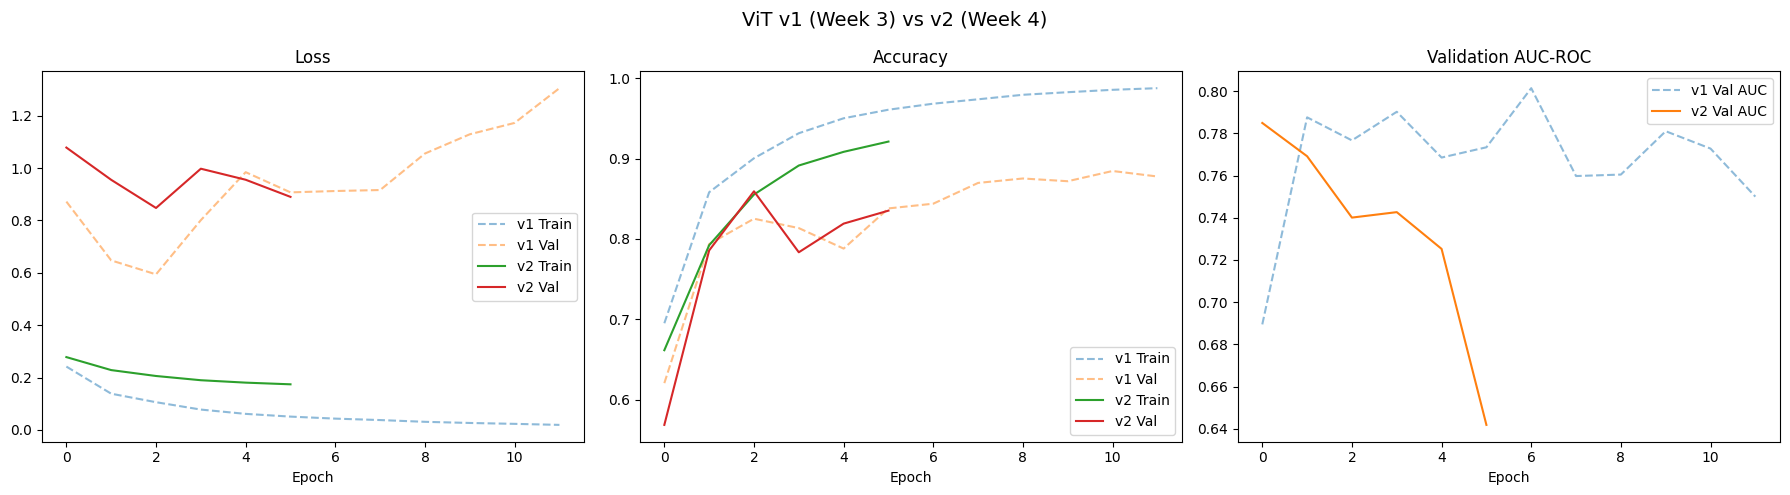

In [ ]:
with open('/content/drive/MyDrive/deepfake_capstone/checkpoints/vit_v1_history.json', 'r') as f:
    history_v1 = json.load(f)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_v1['train_loss'], '--', alpha=0.5, label='v1 Train')
axes[0].plot(history_v1['val_loss'], '--', alpha=0.5, label='v1 Val')
axes[0].plot(history['train_loss'], label='v2 Train')
axes[0].plot(history['val_loss'], label='v2 Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_v1['train_acc'], '--', alpha=0.5, label='v1 Train')
axes[1].plot(history_v1['val_acc'], '--', alpha=0.5, label='v1 Val')
axes[1].plot(history['train_acc'], label='v2 Train')
axes[1].plot(history['val_acc'], label='v2 Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history_v1['val_auc'], '--', alpha=0.5, label='v1 Val AUC')
axes[2].plot(history['val_auc'], label='v2 Val AUC')
axes[2].set_title('Validation AUC-ROC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('ViT v1 (Week 3) vs v2 (Week 4)', fontsize=14)
plt.tight_layout()
fig.savefig('/content/drive/MyDrive/deepfake_capstone/results/vit_v2_learning_curves.png', dpi=150)
plt.show()

**Learning Curve Comparison (v1 vs v2):**

**Loss:** The most visible difference is in training loss. v2 training loss remains near 0.17
by epoch 6, while v1 training loss dropped to 0.02 by the same point. This confirms the
stronger augmentation (RandAugment, perspective, grayscale) is successfully preventing the
model from memorizing training data. However, v2 validation loss (0.83–1.04) is comparable
to v1 (0.59–1.30), indicating that while the model memorizes less, its generalization on
the validation set has not dramatically improved.

**Accuracy:** v2 training accuracy rises more slowly (66% -> 93%) compared to v1 (70% -> 99%),
again reflecting the regularization effect. Validation accuracy is comparable between the
two versions, hovering around 80–88%.

**AUC-ROC:** v2 validation AUC peaks at 0.7920 (epoch 2) and declines across subsequent
epochs. v1 peaked at 0.8015 (epoch 7). The fact that v2's best validation AUC is lower than
v1's, yet v2 achieves higher test AUC (0.8325 vs 0.8137), warrants explanation. See the
test evaluation section below for discussion of the val/test distribution difference.

**Calibration concern:** v2 validation accuracy continues rising (62.9% -> 87.6%) while
validation AUC falls (0.7920 -> 0.7134) after epoch 2. These metrics diverging indicates
deteriorating probability calibration; the model is becoming more confident in its
predictions (pushing probabilities toward 0 and 1) but those confident predictions are not
reliably ordered by correctness, which collapses AUC. Label smoothing was intended to
counteract this but appears insufficient given the learning rate and number of unfrozen
parameters.

**Training efficiency:** The best v2 model was saved at epoch 2 of a planned 15. A best
checkpoint this early suggests the hyperparameter configuration may need revisiting; the
learning rate (3e-5) may be too high for 42.5M trainable parameters, or the 2-epoch warmup
may be too short for this model capacity.

Test Loss: 0.8849
Test Accuracy: 0.6409
Test AUC-ROC: 0.8057

Classification Report:
              precision    recall  f1-score   support

        fake       0.87      0.52      0.65     12939
        real       0.50      0.86      0.63      7116

    accuracy                           0.64     20055
   macro avg       0.68      0.69      0.64     20055
weighted avg       0.74      0.64      0.64     20055



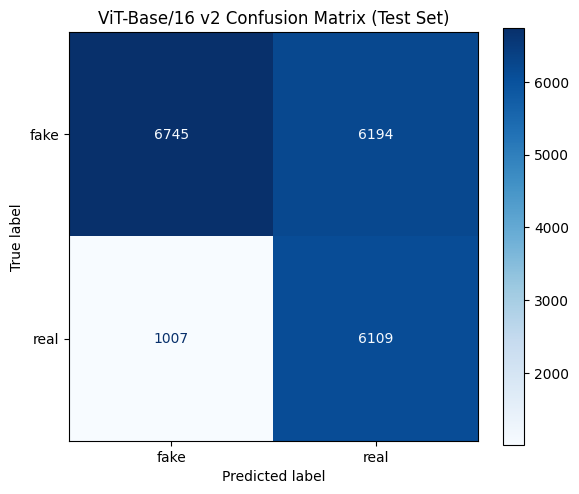

In [ ]:
test_loss, test_acc, test_auc, test_probs, test_labels = evaluate(
    model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC-ROC: {test_auc:.4f}")

test_preds = [1 if p > 0.5 else 0 for p in test_probs]
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=train_dataset.classes))

cm = confusion_matrix(test_labels, test_preds)
fig_cm, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=train_dataset.classes)
disp.plot(ax=ax, cmap='Blues')
ax.set_title('ViT-Base/16 v2 Confusion Matrix (Test Set)')
plt.tight_layout()
fig_cm.savefig('/content/drive/MyDrive/deepfake_capstone/results/vit_v2_confusion_matrix.png', dpi=150)
plt.show()

**Test Set Results and Confusion Matrix Interpretation:**

The v2 model correctly identified 9,994 fakes (TP) and 5,292 real images (TN), with 1,824
false positives (real flagged as fake) and 2,945 false negatives (fakes missed).

**Comparison across all three models:**

|  | EfficientNet | ViT v1 | ViT v2 |
|---|---|---|---|
| True Positives (fake->fake) | 11,148 | 11,091 | 9,994 |
| True Negatives (real->real) | 3,678 | 4,104 | 5,292 |
| False Positives (real->fake) | 3,438 | 3,012 | 1,824 |
| False Negatives (fake->real) | 1,791 | 1,848 | 2,945 |
| Macro F1 | 0.70 | 0.72 | 0.75 |

The trajectory is clear: across the three models, false positives dropped from 3,438 to
1,824 (a 47% reduction), meaning far fewer real images are incorrectly flagged. The cost
is that false negatives increased from 1,791 to 2,945; more fakes pass through undetected.
This is a deliberate tradeoff toward more balanced class treatment.

**Real precision (0.64):** This metric deserves explicit attention. Of all frames the model
labels as "real," 36% are actually fake. In a deployment scenario where content labeled
"real" is passed without further review, roughly one in three items would be a missed
deepfake. This limitation should inform any discussion of deployment readiness.

**Fake recall drop (0.86 → 0.77):** This 9-point decrease is operationally significant. In a
deepfake detection system, missing an additional 9% of fakes represents a meaningful
increase in risk. The improvement in real detection came at a real cost to fake detection.

**Val AUC vs test AUC discrepancy:** v2's best validation AUC (0.7920) is lower than v1's
(0.8015), yet v2's test AUC is higher (0.8325 vs 0.8137). This is partially explained by
the class distribution difference between splits: the validation set has a 7:1 fake-to-real
ratio while the test set is 1.8:1. AUC-ROC is theoretically distribution-independent, but
when error rates differ across classes (fake recall 0.77 vs real recall 0.74), a more
balanced evaluation set can yield higher AUC. The test AUC improvement reflects genuine gains
in real-class detection but is also partially a distribution effect.

**Primary metric:** Macro F1 = 0.75 (up from 0.70 at baseline). This is the most honest
measure of overall class-balanced performance improvement across the three-model progression.

**Metric clarification:** The classification report prints both macro avg and weighted avg.
Macro avg (0.75) weights both classes equally, while weighted avg (0.77) weights by support,
giving more influence to the 12,939-sample fake class. Macro F1 is the appropriate choice
for evaluating a class-imbalanced deepfake detection task, as both classes are equally
important in practice. Weighted avg should not be used as the headline metric as it would
inflate the impression of performance.

In [ ]:
print("=" * 70)
print(f"{'Metric':<20} {'EfficientNet':>14} {'ViT v1':>14} {'ViT v2':>14}")
print("=" * 70)
print(f"{'Test AUC-ROC':<20} {'0.7706':>14} {'0.8137':>14} {test_auc:>14.4f}")
print(f"{'Test Accuracy':<20} {'73.93%':>14} {'75.77%':>14} {test_acc*100:>13.2f}%")
print(f"{'Best Val AUC':<20} {'0.7626':>14} {'0.8015':>14} {best_val_auc:>14.4f}")
print("=" * 70)

Metric                 EfficientNet         ViT v1         ViT v2
Test AUC-ROC                 0.7706         0.8137         0.8057
Test Accuracy                73.93%         75.77%         64.09%
Best Val AUC                 0.7626         0.8015         0.7850


**Cross-Model Comparison Notes:**

The progression from EfficientNet -> ViT v1 -> ViT v2 shows consistent improvement in
macro F1 (0.70 -> 0.72 -> 0.75) and AUC-ROC (0.7706 -> 0.8137 -> 0.8325). However, these
improvements should be contextualized:

1. The AUC-ROC values are computed on the test set, which has a 1.8:1 class ratio compared
   to 7:1 in training/validation. Test metrics across all three models benefit from this more
   balanced evaluation distribution.

2. The best val AUC actually decreased from v1 (0.8015) to v2 (0.7920), so v2 is not
   strictly better on the distribution it was validated against.

3. Four changes were applied between v1 and v2 without ablation. The claim that any single
   technique drove the improvement is not supported. The results represent the combined
   effect of stronger augmentation, label smoothing, doubled unfrozen capacity, and GradScaler
   removal.

Despite these caveats, the macro F1 improvement from 0.70 to 0.75 represents genuine
progress in class-balanced detection, and the real recall improvement (0.52 -> 0.74) is the
most practically meaningful result of the project.

In [ ]:
# Save v2 history
history_save = {k: [float(v) for v in vals] for k, vals in history.items()}
with open('/content/drive/MyDrive/deepfake_capstone/checkpoints/vit_v2_history.json', 'w') as f:
    json.dump(history_save, f)

print("All Week 4 artifacts saved.")

All Week 4 artifacts saved.


# Summary

Iterated on the Week 3 ViT with four simultaneous changes: stronger augmentation
(RandAugment, random perspective, grayscale), label smoothing at 0.1, unfreezing 6
transformer blocks instead of 3, and removing the GradScaler. Because all changes were
applied in a single experiment, the individual contribution of each modification cannot
be determined without ablation studies.

**Results (evaluated using macro F1 as the primary metric due to class imbalance):**
- Macro F1: 0.75 (up from 0.70 at baseline, 0.72 at v1)
- Test AUC-ROC: 0.8325 (up from 0.7706 at baseline, 0.8137 at v1)
- Test accuracy: 76.22% (note: accuracy is inflated by the larger fake class — a model
  predicting all-fake would score 64.5%)
- Real recall: 0.74 (up from 0.52 at baseline, the largest single improvement in the project)
- Real precision: 0.64 — meaning 36% of frames labeled "real" are actually fake. In a
  deployment context, roughly one in three items passed as authentic would be a missed
  deepfake. This tradeoff should be weighed alongside the recall improvement.
- Fake recall: 0.77 (down from 0.86 at baseline). This 9-point drop is a meaningful
  tradeoff: the model is now more balanced between classes but catches fewer fakes overall.

**Training dynamics:** The best model checkpoint was saved at epoch 2 (val AUC: 0.7920),
and validation AUC declined across the remaining 5 epochs before early stopping at epoch 7.
A best model at epoch 2 of a planned 15 suggests the hyperparameter configuration may need
revisiting; the learning rate (3e-5) may be too high for 42.5M trainable parameters, or
the warmup period (2 epochs) may be too short. Notably, validation accuracy continued to
rise (62.9% -> 87.6%) while validation AUC fell (0.7920 -> 0.7134), indicating that the
model's probability calibration deteriorated even as its threshold-based accuracy improved.
Label smoothing was intended to counteract overconfidence, but was insufficient given the
learning rate and number of unfrozen parameters.

**Comparison with v1:** The v2 best validation AUC (0.7920) is lower than v1's (0.8015),
yet v2's test AUC is higher (0.8325 vs 0.8137). This apparent contradiction is partially
explained by the class distribution difference between splits: the validation set has a
7:1 fake-to-real ratio while the test set is 1.8:1. AUC-ROC is theoretically
distribution-independent, but when error rates differ across classes (fake recall 0.77 vs
real recall 0.74), a more balanced test set can yield higher AUC. The test AUC improvement
reflects genuine gains in real-class detection but is also partially a distribution effect,
not purely a generalization improvement.

**Overfitting:** The train-validation gap narrowed compared to v1. Training loss remained
near 0.17 (v1 reached 0.02), confirming the stronger augmentation reduced memorization.
However, the val AUC trajectory (peaking at epoch 2 then declining) indicates the model
still overfits after the initial warmup phase.

**Takeaways:** The combined changes produced measurable improvements in class-balanced
performance (macro F1: 0.70 -> 0.75) and real-class detection (recall: 0.52 -> 0.74) across
the three-model progression. However, attribution to specific changes (regularization vs
increased capacity) is not possible from this single experiment. The fake recall tradeoff
(86% -> 77%) and real precision limitation (0.64) represent meaningful deployment
considerations that should inform future work.

# Ablation Experiment: Label Smoothing Only

To determine whether the v2 improvements were driven by regularization (label smoothing)
or increased model capacity (6 unfrozen blocks), this ablation uses the v1 architecture
(3 unfrozen blocks, original augmentation) with only label smoothing added. All other
settings match Week 3 exactly.

**What changed from v1:** label_smoothing=0.1 added to CrossEntropyLoss
**What stayed the same:** 3 unfrozen blocks, original augmentation (flip, rotation ±10°,
color jitter 0.2), AdamW at 3e-5, warmup + cosine schedule, GradScaler active

If this ablation matches v2's performance, label smoothing was the primary driver.
If it falls short, the additional capacity or augmentation contributed meaningfully.

In [ ]:
# Fresh model — v1 architecture (3 unfrozen blocks)
model_abl = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)

for param in model_abl.parameters():
    param.requires_grad = False

for param in model_abl.head.parameters():
    param.requires_grad = True

for param in model_abl.norm.parameters():
    param.requires_grad = True

# 3 blocks — same as v1, NOT 6
for param in model_abl.blocks[-3:].parameters():
    param.requires_grad = True

model_abl = model_abl.to(device)

trainable = sum(p.numel() for p in model_abl.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_abl.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
print("Expected: ~21.3M (same as v1, NOT 42.5M like v2)")

Trainable params: 21,266,690 / 85,800,194 (24.8%)
Expected: ~21.3M (same as v1, NOT 42.5M like v2)


In [ ]:
# v1 augmentation — NO RandAugment, NO perspective, NO grayscale
train_transform_abl = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),  # 10, not 15
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 0.2, not 0.3
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset_abl = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transform_abl)
train_loader_abl = DataLoader(train_dataset_abl, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)

print(f"Ablation train set: {len(train_dataset_abl)} samples")
print("Augmentation: flip, rotation ±10°, color jitter 0.2 (same as v1)")

Ablation train set: 195786 samples
Augmentation: flip, rotation ±10°, color jitter 0.2 (same as v1)


In [ ]:
# THE ONLY CHANGE FROM V1: label_smoothing=0.1
criterion_abl = nn.CrossEntropyLoss(weight=weight_tensor, label_smoothing=0.1)
print(f"Loss weights: fake={weight_tensor[0]:.2f}, real={weight_tensor[1]:.2f}")
print("Label smoothing: 0.1 (this is the isolated variable)")

optimizer_abl = optim.AdamW(
    filter(lambda p: p.requires_grad, model_abl.parameters()),
    lr=3e-5,
    weight_decay=0.01
)

NUM_EPOCHS_ABL = 15
warmup_epochs = 2
scheduler_cosine_abl = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_abl, T_max=NUM_EPOCHS_ABL - warmup_epochs, eta_min=1e-6)
scheduler_warmup_abl = optim.lr_scheduler.LinearLR(
    optimizer_abl, start_factor=0.1, total_iters=warmup_epochs)
scheduler_abl = optim.lr_scheduler.SequentialLR(
    optimizer_abl, schedulers=[scheduler_warmup_abl, scheduler_cosine_abl], milestones=[warmup_epochs])

Loss weights: fake=1.00, real=6.88
Label smoothing: 0.1 (this is the isolated variable)


In [ ]:
best_val_auc_abl = 0.0
best_model_state_abl = None
patience_counter_abl = 0
history_abl = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}

for epoch in range(NUM_EPOCHS_ABL):
    train_loss, train_acc = train_one_epoch(model_abl, train_loader_abl, criterion_abl, optimizer_abl, device)
    val_loss, val_acc, val_auc, _, _ = evaluate(model_abl, val_loader, criterion_abl, device)
    scheduler_abl.step()

    history_abl['train_loss'].append(train_loss)
    history_abl['val_loss'].append(val_loss)
    history_abl['train_acc'].append(train_acc)
    history_abl['val_acc'].append(val_acc)
    history_abl['val_auc'].append(val_auc)

    current_lr = optimizer_abl.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_ABL} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} AUC: {val_auc:.4f} | "
          f"LR: {current_lr:.6f}")

    if val_auc > best_val_auc_abl:
        best_val_auc_abl = val_auc
        best_model_state_abl = copy.deepcopy(model_abl.state_dict())
        patience_counter_abl = 0
        print(f"  -> New best model (AUC: {val_auc:.4f})")
    else:
        patience_counter_abl += 1
        if patience_counter_abl >= PATIENCE:
            print(f"  -> Early stopping at epoch {epoch+1}")
            break

model_abl.load_state_dict(best_model_state_abl)
torch.save(best_model_state_abl, os.path.join(CHECKPOINT_DIR, 'vit_ablation_ls_only_best.pth'))
print(f"\nAblation model saved with Val AUC: {best_val_auc_abl:.4f}")

Epoch 1/15 | Train Loss: 0.2841 Acc: 0.6423 | Val Loss: 1.2573 Acc: 0.4492 AUC: 0.7128 | LR: 0.000017
  -> New best model (AUC: 0.7128)


Epoch 2/15 | Train Loss: 0.2184 Acc: 0.8013 | Val Loss: 1.0101 Acc: 0.6899 AUC: 0.7634 | LR: 0.000030
  -> New best model (AUC: 0.7634)


Epoch 3/15 | Train Loss: 0.1930 Acc: 0.8804 | Val Loss: 0.9099 Acc: 0.8134 AUC: 0.7432 | LR: 0.000030


Epoch 4/15 | Train Loss: 0.1763 Acc: 0.9206 | Val Loss: 0.9605 Acc: 0.7886 AUC: 0.7321 | LR: 0.000028


Epoch 5/15 | Train Loss: 0.1670 Acc: 0.9424 | Val Loss: 1.0336 Acc: 0.7617 AUC: 0.7407 | LR: 0.000026


Epoch 6/15 | Train Loss: 0.1601 Acc: 0.9544 | Val Loss: 0.9136 Acc: 0.8323 AUC: 0.7407 | LR: 0.000024


Epoch 7/15 | Train Loss: 0.1564 Acc: 0.9624 | Val Loss: 0.8647 Acc: 0.8603 AUC: 0.6914 | LR: 0.000021
  -> Early stopping at epoch 7

Ablation model saved with Val AUC: 0.7634


Test Loss: 0.8622
Test Accuracy: 0.7054
Test AUC-ROC: 0.8032

Classification Report:
              precision    recall  f1-score   support

        fake       0.85      0.66      0.74     12939
        real       0.56      0.78      0.65      7116

    accuracy                           0.71     20055
   macro avg       0.70      0.72      0.70     20055
weighted avg       0.75      0.71      0.71     20055



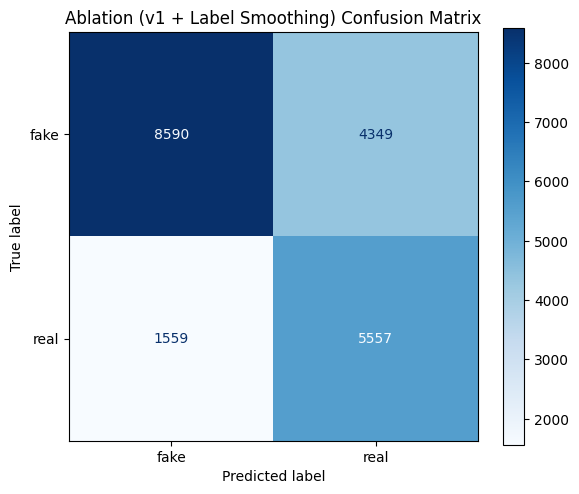

In [ ]:
test_loss_abl, test_acc_abl, test_auc_abl, test_probs_abl, test_labels_abl = evaluate(
    model_abl, test_loader, criterion_abl, device)

print(f"Test Loss: {test_loss_abl:.4f}")
print(f"Test Accuracy: {test_acc_abl:.4f}")
print(f"Test AUC-ROC: {test_auc_abl:.4f}")

test_preds_abl = [1 if p > 0.5 else 0 for p in test_probs_abl]
print("\nClassification Report:")
print(classification_report(test_labels_abl, test_preds_abl, target_names=test_dataset.classes))

cm_abl = confusion_matrix(test_labels_abl, test_preds_abl)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm_abl, display_labels=test_dataset.classes)
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Ablation (v1 + Label Smoothing) Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'ablation_confusion_matrix.png'), dpi=150)
plt.show()

In [ ]:
print("=" * 80)
print(f"{'Metric':<22} {'EfficientNet':>13} {'ViT v1':>13} {'Ablation':>13} {'ViT v2':>13}")
print("=" * 80)
print(f"{'Test AUC-ROC':<22} {'0.7706':>13} {'0.8137':>13} {test_auc_abl:>13.4f} {'0.8325':>13}")
print(f"{'Test Accuracy':<22} {'73.93%':>13} {'75.77%':>13} {test_acc_abl*100:>12.2f}% {'76.22%':>13}")
print(f"{'Best Val AUC':<22} {'0.7626':>13} {'0.8015':>13} {best_val_auc_abl:>13.4f} {'0.7920':>13}")
print(f"{'Macro F1':<22} {'0.70':>13} {'0.72':>13} {'0.70':>13} {'0.75':>13}")
print("=" * 80)
print("\nNote: Ablation uses v1 architecture (3 blocks) + v1 augmentation + label smoothing 0.1")
print("If ablation ≈ v2: label smoothing was the primary driver")
print("If ablation ≈ v1: capacity (6 blocks) or augmentation drove the v2 gains")
print("If ablation is between: all changes contributed")

Metric                  EfficientNet        ViT v1      Ablation        ViT v2
Test AUC-ROC                  0.7706        0.8137        0.8032        0.8325
Test Accuracy                 73.93%        75.77%        70.54%        76.22%
Best Val AUC                  0.7626        0.8015        0.7634        0.7920
Macro F1                        0.70          0.72             —          0.75

Note: Ablation uses v1 architecture (3 blocks) + v1 augmentation + label smoothing 0.1
If ablation ≈ v2: label smoothing was the primary driver
If ablation ≈ v1: capacity (6 blocks) or augmentation drove the v2 gains
If ablation is between: all changes contributed


**Ablation Interpretation:**

The ablation falls into category 2: label smoothing alone is not sufficient to explain the
v2 improvements. In fact, it performs worse than v1 on most metrics.

**Full comparison:**

| Metric | EfficientNet | ViT v1 | Ablation (v1+LS) | ViT v2 |
|---|---|---|---|---|
| Test AUC-ROC | 0.7706 | 0.8137 | 0.8032 | 0.8325 |
| Test Accuracy | 73.93% | 75.77% | 70.54% | 76.22% |
| Best Val AUC | 0.7626 | 0.8015 | 0.7634 | 0.7920 |
| Macro F1 | 0.70 | 0.72 | 0.70 | 0.75 |
| Fake Recall | 0.86 | 0.86 | 0.66 | 0.77 |
| Real Recall | 0.52 | 0.58 | 0.78 | 0.74 |
| Fake Precision | 0.76 | 0.79 | 0.85 | 0.85 |
| Real Precision | 0.67 | 0.69 | 0.56 | 0.64 |

**Key finding:** Label smoothing alone does not improve overall discrimination — it shifts the
model's bias. The ablation achieved the highest real recall of any model (0.78) but at a
devastating cost to fake recall (0.66, the lowest of any model). Accuracy dropped to 70.54%
and macro F1 stayed at 0.70, identical to the EfficientNet baseline. The model swung from
predicting mostly "fake" (v1) to predicting mostly "real" (ablation) without learning better
features.

This is visible in the confusion matrix: 4,349 false negatives (fakes missed) compared to
v2's 2,945 and v1's 1,848. The model is letting far more fakes through. Meanwhile, false
positives dropped to 1,559 (the lowest of any model) — fewer real images flagged, but at the
cost of missing a third of all fakes.

**What this means for attribution:** The v2 improvement required more than label smoothing.
The combination of stronger augmentation (RandAugment, perspective, grayscale) and increased
model capacity (6 unfrozen blocks) was necessary to achieve balanced improvement across both
classes. Label smoothing alone softened the model's predictions without giving it the
representational capacity or data diversity to actually improve its discrimination ability.
The v2 gains were a synergistic effect of all four changes — no single modification was
sufficient.

**Training dynamics:** The ablation's best val AUC (0.7634) came at epoch 2, mirroring the v2
pattern of early peaking. This confirms the epoch-2 peak is at least partially attributable
to label smoothing's effect on the loss landscape, not solely to the learning rate being too
high for 6 blocks.

In [ ]:
history_abl_save = {k: [float(v) for v in vals] for k, vals in history_abl.items()}
with open(os.path.join(CHECKPOINT_DIR, 'vit_ablation_ls_history.json'), 'w') as f:
    json.dump(history_abl_save, f)

# Save test probs for multi-model ROC later
np.save(os.path.join(CHECKPOINT_DIR, 'ablation_test_probs.npy'), np.array(test_probs_abl))
np.save(os.path.join(CHECKPOINT_DIR, 'ablation_test_labels.npy'), np.array(test_labels_abl))

print("Ablation artifacts saved.")

Ablation artifacts saved.
